# Baku, before lights out

Predicting the 2026 Azerbaijan Grand Prix finishing order from practice, qualifying and recent form.
The forecast is frozen at **25 September 2026, 14:43 UTC**, with a provisional starting grid.

The saved outputs are ready to read. To rerun in Colab, upload the workbook, grid CSV and
weather JSON from `data/` when prompted.

## Setup

If this cell installs packages, restart the kernel once before running the rest.

In [1]:
import importlib.metadata
import subprocess
import sys

packages = {
    "fastf1": "3.6.1",
    "openpyxl": "3.1.5",
    "requests": "2.32.4",
    "numpy": "2.2.6",
    "pandas": "2.2.3",
    "matplotlib": "3.10.3",
    "scipy": "1.15.3",
    "scikit-learn": "1.6.1",
    "xgboost": "3.0.5",
}
if globals().get("restart_needed", False):
    raise RuntimeError("Restart the kernel, then run all cells.")
missing = []
for name, version in packages.items():
    try:
        installed = importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        installed = None
    if installed != version:
        missing.append(f"{name}=={version}")
if missing:
    restart_needed = True
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    raise RuntimeError("Setup complete. Restart the kernel, then run all cells.")

In [2]:
from pathlib import Path
from collections import defaultdict
import json
import time
import tempfile
import unicodedata
import fastf1
import numpy as np
import numpy.strings
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from IPython.utils.capture import capture_output

SEED = 42
AS_OF_UTC = pd.Timestamp("2026-09-25T14:43:00Z")
START_YEAR, TARGET_YEAR = 2018, 2026
TARGET_ROUND = 15
RACE_START = pd.Timestamp("2026-09-26T11:00:00Z")
TIMING_START_YEAR = 2023
N_SIMULATIONS = 6000
OUT = Path("results")
OUT.mkdir(exist_ok=True)
CACHE = Path(tempfile.gettempdir()) / "baku-fastf1-2026"
CACHE.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE))
fastf1.set_log_level("WARNING")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "font.size": 10,
    }
)


def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / f"{name}.png", bbox_inches="tight")
    plt.show()

## Get the data

FastF1 provides historical results, qualifying and available lap data. The workbook supplies
this weekend's practice and qualifying; the grid CSV adds documented penalties. Weather is
read from the timestamped JSON and shown as context, since comparable historical pre-race
forecasts are unavailable. The first run downloads session data and can take a while.

In [3]:
def retry(fn, attempts=4):
    for attempt in range(attempts):
        try:
            return fn()
        except Exception as exc:
            if attempt == attempts - 1:
                raise
            delay = (
                min(60, 20 * (attempt + 1))
                if "Too Many Requests" in str(exc)
                else 2 ** attempt
            )
            print(
                f"Retrying public data request in {delay}s: {type(exc).__name__}",
                flush=True,
            )
            time.sleep(delay)


def name_key(value):
    value = (
        unicodedata.normalize("NFKD", str(value))
        .encode("ascii", "ignore")
        .decode()
        .lower()
    )
    return "".join(c for c in value if c.isalnum())


def seconds(value):
    if pd.isna(value) or str(value).strip() in ("", "-", "DNF", "DNS", "No time"):
        return np.nan
    if isinstance(value, (pd.Timedelta,)):
        return value.total_seconds()
    s = str(value).strip().strip('"').strip("'").rstrip("s").lstrip("+")
    if ":" in s:
        parts = [float(x) for x in s.split(":")]
        return sum(x * 60 ** i for i, x in enumerate(parts[::-1]))
    return float(s)


def qualify_features(q):
    q = q.copy()
    n = len(q)
    q["qual_norm"] = (q.qual_pos - 1) / max(n - 1, 1)
    for seg in ["Q1", "Q2", "Q3"]:
        q[seg] = q[seg].map(seconds)
        best = q[seg].min()
        q[f"{seg.lower()}_gap_pct"] = 100 * (q[seg] / best - 1)
    # Q1 has broadest coverage. Never compare a Q1 time with a Q3 pole time.
    q["qual_teammate_gap"] = q.q1_gap_pct - q.groupby(
        "constructorId"
    ).q1_gap_pct.transform("mean")
    q["team_qual_norm"] = q.groupby("constructorId").qual_norm.transform("mean")
    return q


def read_weekend(path):
    book = pd.read_excel(path, sheet_name=None)
    tabs = {name_key(k): v.dropna(how="all") for k, v in book.items()}
    keys = [k for k in tabs if k.startswith("qual")]
    if len(keys) != 1:
        raise ValueError("Workbook must contain exactly one qualifying tab.")
    q = tabs[keys[0]].rename(
        columns={
            "Pos.": "qual_pos",
            "No.": "number",
            "Driver": "driver",
            "Team": "team",
        }
    )
    required = {"qual_pos", "number", "driver", "team", "Q1", "Q2", "Q3"}
    if not required <= set(q):
        raise ValueError(f"Qualifying missing columns: {required - set(q)}")
    q["name_key"] = q.driver.map(name_key)
    if not q.name_key.is_unique or not q.number.is_unique:
        raise ValueError("Duplicate qualifying identity.")
    q.qual_pos = pd.to_numeric(q.qual_pos, errors="raise").astype(int)
    if sorted(q.qual_pos) != list(range(1, len(q) + 1)):
        raise ValueError("Qualifying positions must be a complete unique order.")
    practice = []
    for session in ["fp1", "fp2", "fp3"]:
        if session not in tabs:
            continue
        p = tabs[session].rename(
            columns={
                "Pos.": "practice_pos",
                "No.": "number",
                "Driver": "driver",
                "Team": "team",
                "Laps": "laps",
            }
        )
        p["name_key"] = p.driver.map(name_key)
        if not p.name_key.is_unique or not set(p.name_key) <= set(q.name_key):
            raise ValueError(f"{session}: duplicate or unknown drivers.")
        leader = p.loc[p.practice_pos.eq(1), "Time / Gap"]
        if len(leader) != 1 or ":" not in str(leader.iloc[0]):
            raise ValueError(f"{session}: leader must have an absolute lap time.")
        best = seconds(leader.iloc[0])

        def lap_time(v):
            return seconds(v) if ":" in str(v) else best + seconds(v)

        p["best_seconds"] = p["Time / Gap"].map(lap_time)
        p["gap_pct"] = 100 * (p.best_seconds / best - 1)
        p["session"] = session.upper()
        practice.append(p)
    return q, pd.concat(practice, ignore_index=True) if practice else pd.DataFrame()


def season_table(year, kind, cache, snapshot="2026-09-25"):
    from fastf1.ergast import Ergast

    cache = Path(cache)
    cache.mkdir(parents=True, exist_ok=True)
    path = cache / f"{kind}_{year}_{snapshot}.pkl"
    if path.exists():
        return pd.read_pickle(path)  # Only load your own generated cache.
    api = Ergast(limit=1000)
    fn = api.get_race_results if kind == "results" else api.get_qualifying_results
    time.sleep(1.5)
    page = retry(lambda: fn(season=year))
    chunks, received = [], 0
    while True:
        for (_, meta), result in zip(page.description.iterrows(), page.content):
            f = pd.DataFrame(result).copy()
            for col in [
                "season",
                "round",
                "raceDate",
                "raceTime",
                "circuitId",
                "raceName",
            ]:
                if col in meta:
                    f[col] = meta[col]
            chunks.append(f)
            received += len(f)
        if received >= page.total_results:
            break
        time.sleep(1.5)
        page = retry(page.get_next_result_page)
    frame = pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()
    if not frame.empty:
        if frame.duplicated(["season", "round", "driverId"]).any():
            raise ValueError("Duplicate API results across pages.")
        frame.to_pickle(path)
    return frame


def load_history(start_year, target_year, race_start, cache, snapshot):
    results, quals = [], []
    for year in range(start_year, target_year + 1):
        print(f"Historical results and qualifying: {year}", flush=True)
        results.append(season_table(year, "results", cache, snapshot))
        quals.append(season_table(year, "qualifying", cache, snapshot))
    r, q = pd.concat(results, ignore_index=True), pd.concat(quals, ignore_index=True)
    r["date"] = pd.to_datetime(r.raceDate, utc=True)
    # Exclude the entire target day; no target-race labels enter any computation.
    r = r.loc[r.date < pd.Timestamp(race_start).normalize()].copy()
    r["race_id"] = r.season.astype(str) + "-" + r["round"].astype(str).str.zfill(2)
    r["position"] = pd.to_numeric(r.position, errors="raise")
    r["grid"] = pd.to_numeric(r.grid, errors="raise")
    r["driver"] = r.givenName + " " + r.familyName
    r["team"] = r.constructorName
    r["n"] = r.groupby("race_id").driverId.transform("size")
    r["finish_norm"] = (r.position - 1) / (r.n - 1)
    # Non-finish proxy includes accidents, mechanical failures and exclusions.
    # It is explicitly not a pure mechanical-failure probability.
    r["nonfinish"] = (
        ~r.status.fillna("").str.match(r"^(Finished|Lapped|\+\d+ Laps?)$")
    ).astype(float)
    r["gain_norm"] = (r.grid.where(r.grid.gt(0)) - r.position) / (r.n - 1)
    if r.duplicated(["race_id", "driverId"]).any():
        raise ValueError("Duplicate history keys.")
    for race, g in r.groupby("race_id"):
        if len(g) < 18 or sorted(g.position) != list(range(1, len(g) + 1)):
            raise ValueError(f"Incomplete finishing classification: {race}")
    q = q.rename(columns={"position": "qual_pos"})
    for col in ["Q1", "Q2", "Q3"]:
        if col not in q:
            q[col] = np.nan
    q = q[["season", "round", "driverId", "qual_pos", "Q1", "Q2", "Q3"]]
    r = r.merge(
        q, on=["season", "round", "driverId"], how="left", validate="one_to_one"
    )
    coverage = r.groupby("race_id").qual_pos.apply(lambda x: x.notna().mean())
    if (coverage < 0.8).any():
        raise ValueError(
            f"Qualifying coverage below 80%: {coverage[coverage < .8].to_dict()}"
        )
    r = pd.concat(
        [qualify_features(g) for _, g in r.groupby("race_id")], ignore_index=True
    )
    r["grid_norm"] = (r.grid.where(r.grid.gt(0), r.n + 1) - 1) / (r.n - 1)
    return r.sort_values(["date", "race_id", "driverId"]).reset_index(drop=True)


def match_field(q, history):
    lookup = history.sort_values("date").drop_duplicates("driverId", keep="last").copy()
    lookup["name_key"] = lookup.driver.map(name_key)
    # Explicit spelling aliases, never fuzzy joins or car-number joins.
    aliases = {"kimiantonelli": "andreakimiantonelli", "alexalbon": "alexanderalbon"}
    available = set(lookup.name_key)
    q = q.copy()
    q.name_key = q.name_key.map(
        lambda x: aliases.get(x, x) if aliases.get(x, x) in available else x
    )
    f = q.merge(
        lookup[["name_key", "driverId"]],
        on="name_key",
        how="left",
        validate="one_to_one",
    )
    if f.driverId.isna().any():
        raise ValueError(
            "Unmatched drivers; add a verified alias: "
            + ", ".join(f.loc[f.driverId.isna(), "driver"])
        )
    # Resolve constructors from current-season IDs, allowing known display-name changes.
    teams = (
        history.loc[history.season.eq(history.season.max())]
        .sort_values("date")
        .drop_duplicates("constructorId", keep="last")
    )
    tm = dict(zip(teams.team.map(name_key), teams.constructorId))
    tm_alias = {
        "redbullracing": "red_bull",
        "haasf1team": "haas",
        "racingbulls": "rb",
        "alpine": "alpine",
        "audi": "audi",
        "cadillac": "cadillac",
    }
    known_ids = set(teams.constructorId)

    def team_id(t):
        k = name_key(t)
        if k in tm:
            return tm[k]
        alias = tm_alias.get(k)
        if alias in known_ids:
            return alias
        raise ValueError(f"Unmapped constructor: {t}; available: {tm}")

    f["constructorId"] = f.team.map(team_id)
    return qualify_features(f)


def add_weekend_summary(field, practice):
    f = field.copy()
    # Preserve original name matching for practice, including accented spellings.
    f["_join"] = f.driver.map(name_key)
    for sess in ["FP1", "FP2", "FP3"]:
        p = practice.loc[
            practice.session.eq(sess), ["name_key", "gap_pct", "laps"]
        ].copy()
        p.columns = ["_join", f"{sess.lower()}_gap_pct", f"{sess.lower()}_laps"]
        f = f.merge(p, on="_join", how="left", validate="one_to_one")
    f["fp2_team_gap_pct"] = f.groupby("constructorId").fp2_gap_pct.transform("mean")
    return f.drop(columns="_join")


def apply_grid(field, path, cutoff):
    f = field.copy()
    f["grid"] = f.qual_pos
    f["grid_source"] = "Qualifying proxy; penalties/pit-lane starts unconfirmed"
    f["grid_status"] = "Qualifying proxy; penalties/pit-lane starts unconfirmed"
    if Path(path).exists():
        g = pd.read_csv(path)
        if "grid_status" not in g:
            g["grid_status"] = "User-supplied grid; confirmation status unspecified"
        required = {"driverId", "grid", "source_url", "published_at"}
        if (
            not required <= set(g)
            or set(g.driverId) != set(f.driverId)
            or not g.driverId.is_unique
        ):
            raise ValueError(
                "Grid CSV must contain one sourced row per entered driver."
            )
        if (
            g[list(required)].isna().any().any()
            or (pd.to_datetime(g.published_at, utc=True) > cutoff).any()
        ):
            raise ValueError("Grid source missing or published after cutoff.")
        if ((g.grid < 0) | (g.grid > len(f))).any() or g.loc[
            g.grid.gt(0), "grid"
        ].duplicated().any():
            raise ValueError("Invalid starting grid; use 0 for pit-lane starters.")
        f = f.drop(columns=["grid", "grid_source", "grid_status"]).merge(
            g.rename(columns={"source_url": "grid_source"}),
            on="driverId",
            validate="one_to_one",
        )
    f["grid_norm"] = (f.grid.where(f.grid.gt(0), len(f) + 1) - 1) / (len(f) - 1)
    return f

In [4]:
def summarize_laps(laps, results, identity_map=None):
    """Same definitions for past FP2 and target FP2; no race-lap features."""
    l = pd.DataFrame(laps).copy()
    l["sec"] = pd.to_timedelta(l.LapTime).dt.total_seconds()
    mapping = (
        identity_map
        if identity_map is not None
        else dict(zip(results.DriverNumber.astype(str), results.DriverId))
    )
    mapping = {str(k): v for k, v in mapping.items() if pd.notna(v) and str(v).strip()}
    l["driverId"] = l.DriverNumber.astype(str).map(mapping)
    l = l.loc[l.driverId.notna()]
    clean = l.loc[
        l.IsAccurate.fillna(False)
        & l.PitInTime.isna()
        & l.PitOutTime.isna()
        & l.TrackStatus.astype(str).eq("1")
        & l.sec.notna()
    ].copy()
    if clean.empty:
        return pd.DataFrame()
    # Within-session compound/time-bin centering reduces, but cannot remove,
    # fuel, compound and track-evolution confounding.
    clean["time_bin"] = (pd.to_timedelta(clean.Time).dt.total_seconds() // 600).astype(
        int
    )
    clean["pace_residual"] = clean.sec - clean.groupby(
        ["Compound", "time_bin"]
    ).sec.transform("median")
    valid_fast = l.loc[l.sec.notna()].copy()
    if "Deleted" in valid_fast:
        valid_fast = valid_fast.loc[~valid_fast.Deleted.eq(True)]
    best = valid_fast.groupby("driverId").sec.min()
    rows = []
    for driver, g in clean.groupby("driverId"):
        slopes, pace, ages = [], [], []
        for _, stint in g.groupby(["Stint", "Compound"]):
            stint = stint.sort_values("LapNumber")
            # Require consecutive laps; do not count scattered push laps as long runs.
            block = stint.LapNumber.diff().ne(1).cumsum()
            for _, run in stint.groupby(block):
                run = run.loc[run.sec <= run.sec.median() * 1.07]
                if len(run) >= 5 and run.TyreLife.nunique() >= 4:
                    from scipy.stats import theilslopes

                    slopes.append(theilslopes(run.sec, run.TyreLife).slope)
                    pace.extend(run.pace_residual.tolist())
                    ages.extend(run.TyreLife.tolist())
        rows.append(
            {
                "driverId": driver,
                "fp2_gap_pct": 100 * (best[driver] / best.min() - 1),
                "fp2_laps": int(l.loc[l.driverId.eq(driver), "LapNumber"].nunique()),
                "fp2_longrun_delta": float(np.median(pace)) if pace else np.nan,
                "fp2_stint_slope": float(np.median(slopes)) if slopes else np.nan,
                "fp2_longrun_laps": len(pace),
            }
        )
    return pd.DataFrame(rows)


def load_fp2(year, rnd, cache, identity_map=None):
    import fastf1

    path = Path(cache) / f"fp2_v2_{year}_{rnd}.pkl"
    if path.exists():
        return pd.read_pickle(path)
    absent = Path(cache) / f"fp2_missing_{year}_{rnd}.json"
    if absent.exists():
        raise ValueError(json.loads(absent.read_text())["reason"])
    s = fastf1.get_session(int(year), int(rnd), "FP2")
    s.load(telemetry=False, weather=False, messages=False)
    out = summarize_laps(s.laps, s.results, identity_map)
    if out.empty:
        raise ValueError("No usable FP2 laps")
    if not out.driverId.is_unique or out.driverId.eq("").any():
        raise ValueError("Invalid FP2 driver identities")
    out.to_pickle(path)
    return out


def enrich_fp2(history, cache, since=2023, enabled=True):
    h = history.copy()
    chunks, log = [], []
    if enabled:
        events = h.loc[
            h.season.ge(since), ["season", "round", "race_id"]
        ].drop_duplicates()
        for row in events.itertuples():
            try:
                print(f"FP2 timing {row.race_id}", flush=True)
                f = load_fp2(row.season, row.round, cache)
                f["race_id"] = row.race_id
                chunks.append(f)
                log.append({"race_id": row.race_id, "status": "loaded", "detail": ""})
            except Exception as exc:
                if "Session type 'FP2' does not exist" in str(exc):
                    (
                        Path(cache) / f"fp2_missing_{row.season}_{row.round}.json"
                    ).write_text(json.dumps({"reason": str(exc)}))
                log.append(
                    {
                        "race_id": row.race_id,
                        "status": "unavailable",
                        "detail": str(exc)[:200],
                    }
                )
    cols = [
        "fp2_gap_pct",
        "fp2_laps",
        "fp2_longrun_delta",
        "fp2_stint_slope",
        "fp2_longrun_laps",
    ]
    if chunks:
        h = h.merge(
            pd.concat(chunks),
            on=["race_id", "driverId"],
            how="left",
            validate="one_to_one",
        )
    for c in cols:
        if c not in h:
            h[c] = np.nan
    h["fp2_team_gap_pct"] = h.groupby(
        ["race_id", "constructorId"]
    ).fp2_gap_pct.transform("mean")
    return h, pd.DataFrame(log, columns=["race_id", "status", "detail"])

In [5]:
def load_race_context(year, rnd, cache):
    import fastf1

    path = Path(cache) / f"race_context_v1_{year}_{rnd}.pkl"
    if path.exists():
        return pd.read_pickle(path)
    s = fastf1.get_session(int(year), int(rnd), "R")
    s.load(telemetry=False, weather=True, messages=False)
    weather = s.weather_data
    wet = (
        float(weather.Rainfall.mean() >= 0.05)
        if weather is not None and len(weather)
        else np.nan
    )
    l = pd.DataFrame(s.laps).copy()
    l["sec"] = pd.to_timedelta(l.LapTime).dt.total_seconds()
    l = l.loc[
        l.IsAccurate.fillna(False)
        & l.PitInTime.isna()
        & l.PitOutTime.isna()
        & l.TrackStatus.astype(str).eq("1")
        & l.sec.notna()
    ].copy()
    # Relative race pace from comparable compound, race phase and tyre age.
    # This still includes fuel/traffic confounding; only prior races may use it.
    l["lap_bin"] = l.LapNumber // 5
    l["age_bin"] = l.TyreLife // 5
    grouped = l.groupby(["Compound", "lap_bin", "age_bin"]).sec
    l["residual"] = 100 * (l.sec / grouped.transform("median") - 1)
    l.loc[grouped.transform("size") < 4, "residual"] = np.nan
    mapping = dict(zip(s.results.DriverNumber.astype(str), s.results.DriverId))
    l["driverId"] = l.DriverNumber.astype(str).map(mapping)
    pace = l.groupby("driverId").residual.agg(["median", "count"])
    pace.loc[pace["count"] < 5, "median"] = np.nan
    out = pd.DataFrame({"driverId": list(mapping.values())})
    out["race_pace_delta"] = out.driverId.map(pace["median"])
    out["wet"] = wet
    out["race_id"] = f"{year}-{int(rnd):02d}"
    out["source_url"] = "https://livetiming.formula1.com/"
    out.to_pickle(path)
    return out


def enrich_race_context(history, cache, since=2023, enabled=True):
    h = history.copy()
    chunks = []
    log = []
    if enabled:
        for r in (
            h.loc[h.season.ge(since), ["season", "round", "race_id"]]
            .drop_duplicates()
            .itertuples()
        ):
            try:
                print(f"Prior race pace/weather {r.race_id}", flush=True)
                chunks.append(load_race_context(r.season, r.round, cache))
                log.append({"race_id": r.race_id, "status": "loaded", "detail": ""})
            except Exception as exc:
                log.append(
                    {
                        "race_id": r.race_id,
                        "status": "unavailable",
                        "detail": str(exc)[:200],
                    }
                )
    if chunks:
        extra = pd.concat(chunks, ignore_index=True)
        h = h.merge(
            extra[["race_id", "driverId", "wet", "race_pace_delta"]],
            on=["race_id", "driverId"],
            how="left",
            validate="one_to_one",
            suffixes=("", "_api"),
        )
        for c in ["wet", "race_pace_delta"]:
            if c + "_api" in h:
                h[c] = h[c].fillna(h[c + "_api"])
                h = h.drop(columns=c + "_api")
    for c in ["wet", "race_pace_delta"]:
        if c not in h:
            h[c] = np.nan
    return h, pd.DataFrame(log, columns=["race_id", "status", "detail"])


def weather_snapshot(path, race_start, cutoff, fetch=True):
    """Use a timestamped saved forecast; never replace with realized race weather."""
    path = Path(path)
    if path.exists():
        obj = json.loads(path.read_text())
    elif fetch:
        import requests

        captured = pd.Timestamp.now(tz="UTC")
        if captured > cutoff or captured >= race_start:
            return {
                "status": "unavailable: live retrieval is after cutoff; supply a saved forecast"
            }
        params = {
            "latitude": 40.3725,
            "longitude": 49.8533,
            "hourly": "temperature_2m,precipitation_probability,wind_speed_10m",
            "timezone": "UTC",
            "start_date": race_start.date().isoformat(),
            "end_date": race_start.date().isoformat(),
        }
        response = requests.get(
            "https://api.open-meteo.com/v1/forecast", params=params, timeout=30
        )
        response.raise_for_status()
        obj = {
            "captured_at": captured.isoformat(),
            "source_url": response.url,
            "data": response.json(),
        }
        path.write_text(json.dumps(obj, indent=2))
    else:
        return {"status": "unavailable: no saved pre-race forecast"}
    if pd.Timestamp(obj["captured_at"]) > cutoff:
        raise ValueError("Weather forecast was captured after the prediction cutoff.")
    hourly = pd.DataFrame(obj["data"]["hourly"])
    hourly["time"] = pd.to_datetime(hourly.time, utc=True)
    race_hours = hourly.loc[
        hourly.time.between(race_start, race_start + pd.Timedelta(hours=2))
    ]
    if len(race_hours) < 2:
        raise ValueError("Weather snapshot does not cover the race window.")
    return {
        "status": "forecast context only; no historical forecast training coverage",
        "captured_at": obj["captured_at"],
        "source_url": obj["source_url"],
        "temperature_c": float(race_hours.temperature_2m.mean()),
        "max_hourly_rain_probability": float(
            race_hours.precipitation_probability.max()
        ),
        "max_wind_kmh": float(race_hours.wind_speed_10m.max()),
    }

In [6]:
required_files = ["weekend.xlsx", "grid.csv", "weather_snapshot.json"]
DATA = Path("data") if Path("data/weekend.xlsx").exists() else Path(".")
if not all((DATA / name).exists() for name in required_files):
    try:
        from google.colab import files

        files.upload()
        DATA = Path(".")
    except ImportError:
        raise FileNotFoundError(
            "Place the workbook, grid CSV and weather JSON in data/."
        )

qualifying, practice = read_weekend(DATA / "weekend.xlsx")
with capture_output():
    history = load_history(
        START_YEAR, TARGET_YEAR, RACE_START, CACHE, AS_OF_UTC.date().isoformat()
    )
assert history.season.max() == TARGET_YEAR
assert history.date.max() < AS_OF_UTC < RACE_START
field = add_weekend_summary(match_field(qualifying, history), practice)
field = apply_grid(field, DATA / "grid.csv", AS_OF_UTC)
field["season"] = TARGET_YEAR
field["circuitId"] = "baku"
field["date"] = RACE_START.normalize()
field["race_id"] = f"{TARGET_YEAR}-baku"
field["n"] = len(field)
assert not history.duplicated(["race_id", "driverId"]).any()
assert field.driverId.is_unique

display(
    history.groupby("season").agg(
        races=("race_id", "nunique"), starts=("driverId", "size")
    )
)
print(
    f"Current field: {len(field)} drivers | History through {history.date.max().date()}"
)

,races,starts
season,,
2018,21,420
2019,21,420
2020,17,340
2021,22,440
2022,22,440
2023,22,440
2024,24,479
2025,24,479
2026,14,308


Current field: 22 drivers | History through 2026-09-13


In [7]:
with capture_output():
    history, context_log = enrich_race_context(history, CACHE, since=TIMING_START_YEAR)
    history, timing_log = enrich_fp2(history, CACHE, since=TIMING_START_YEAR)

long_run_columns = ["fp2_longrun_delta", "fp2_stint_slope", "fp2_longrun_laps"]
field[long_run_columns] = np.nan
try:
    weekend_identity = dict(zip(field.number.astype(int).astype(str), field.driverId))
    extra = load_fp2(TARGET_YEAR, TARGET_ROUND, CACHE, identity_map=weekend_identity)
    field = field.drop(columns=long_run_columns).merge(
        extra[["driverId", *long_run_columns]],
        on="driverId",
        how="left",
        validate="one_to_one",
    )
except Exception as exc:
    print(f"Current FP2 long runs unavailable: {exc}")

weather = weather_snapshot(
    DATA / "weather_snapshot.json", RACE_START, AS_OF_UTC, fetch=False
)
display(pd.Series(weather, name="Race-window weather"))
display(
    pd.DataFrame(
        {
            "historical_race_context": context_log.status.value_counts(),
            "historical_FP2": timing_log.status.value_counts(),
        }
    )
    .fillna(0)
    .astype(int)
)
context_log.to_csv(OUT / "race_context_availability.csv", index=False)
timing_log.to_csv(OUT / "timing_availability.csv", index=False)

status                         forecast context only; no historical forecast ...
captured_at                                     2026-09-25T14:42:21.819852+00:00
source_url                     https://api.open-meteo.com/v1/forecast?latitud...
temperature_c                                                          26.266667
max_hourly_rain_probability                                                  0.0
max_wind_kmh                                                                17.6
Name: Race-window weather, dtype: object

,historical_race_context,historical_FP2
status,,
loaded,84,61
unavailable,0,23


## The weekend so far

Practice gaps are fastest-lap comparisons. Only two drivers have enough clean FP2 laps
for the long-run estimate, so long-run pace stays out of the model.

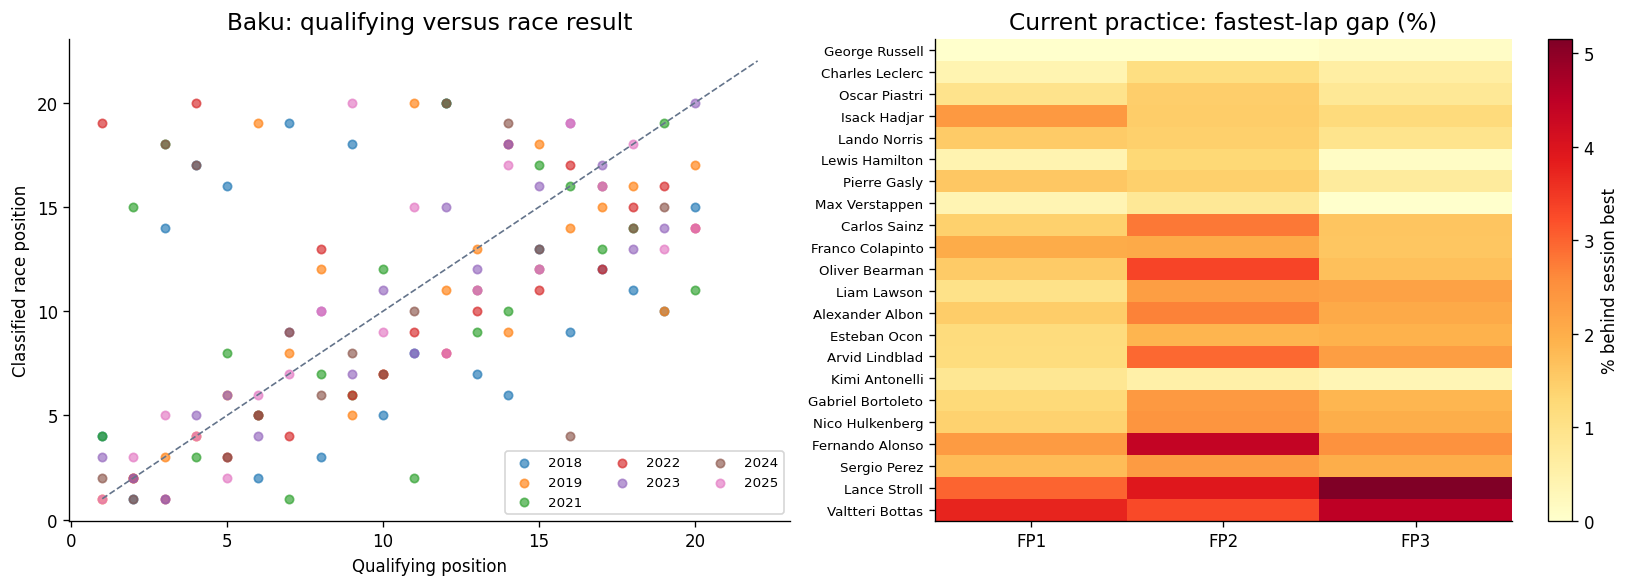

In [8]:
(fig, axes) = plt.subplots(1, 2, figsize=(14, 5))
baku_history = history.loc[history.circuitId.eq("baku")]
for (year, g) in baku_history.groupby("season"):
    axes[0].scatter(g.qual_pos, g.position, alpha=0.65, label=str(year), s=25)
axes[0].plot([1, 22], [1, 22], color="#64748b", linestyle="--", linewidth=1)
axes[0].set(
    xlabel="Qualifying position",
    ylabel="Classified race position",
    title="Baku: qualifying versus race result",
)
axes[0].legend(ncol=3, fontsize=8)
pace = practice.pivot(index="driver", columns="session", values="gap_pct").reindex(
    qualifying.sort_values("qual_pos").driver
)
im = axes[1].imshow(pace, aspect="auto", cmap="YlOrRd")
axes[1].set_yticks(range(len(pace)), pace.index, fontsize=8)
axes[1].set_xticks(range(len(pace.columns)), pace.columns)
axes[1].set_title("Current practice: fastest-lap gap (%)")
fig.colorbar(im, ax=axes[1], label="% behind session best")
savefig("eda_baku_and_practice")

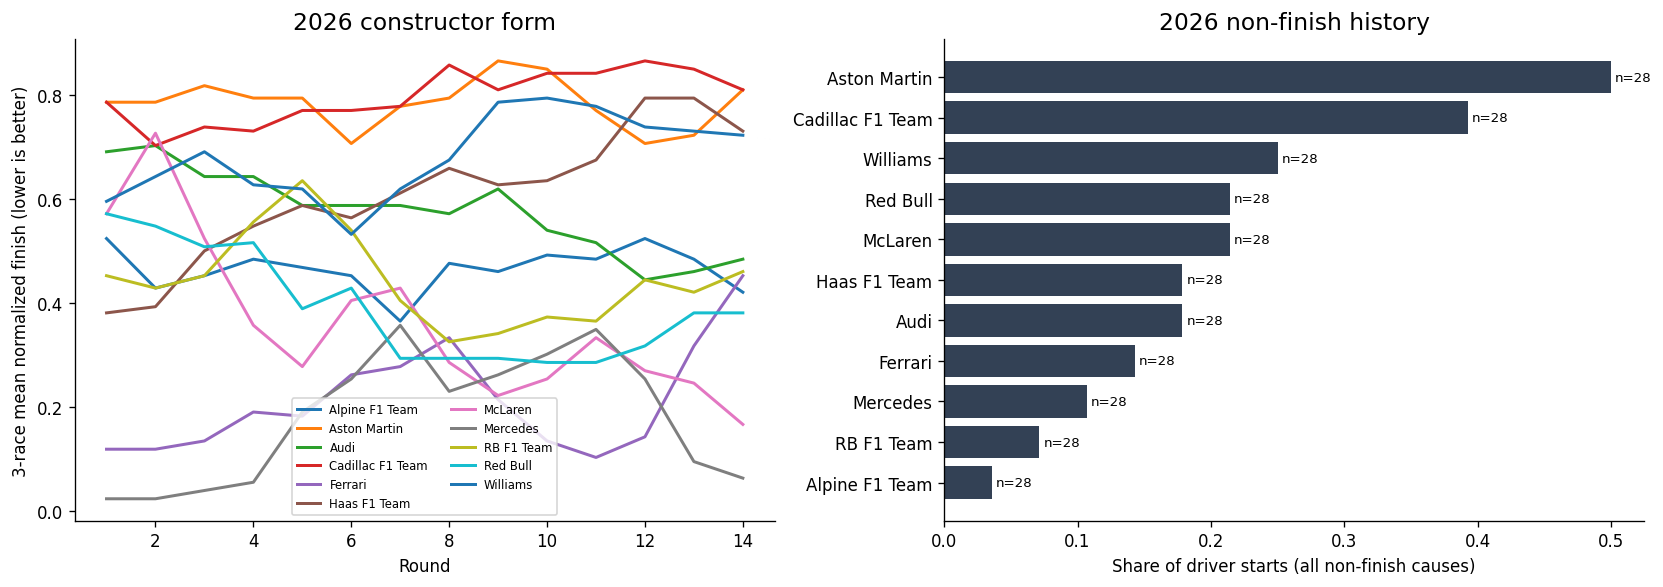

In [9]:
recent = history.loc[history.season.eq(TARGET_YEAR)].copy()
(fig, axes) = plt.subplots(1, 2, figsize=(14, 5))
for (team, g) in recent.groupby("team"):
    means = g.groupby("round").finish_norm.mean().rolling(3, min_periods=1).mean()
    axes[0].plot(means.index, means, label=team, linewidth=1.8)
axes[0].set(
    title="2026 constructor form",
    xlabel="Round",
    ylabel="3-race mean normalized finish (lower is better)",
)
axes[0].legend(fontsize=7, ncol=2)
rel = recent.groupby("team").nonfinish.agg(["mean", "size"]).sort_values("mean")
axes[1].barh(rel.index, rel["mean"], color="#334155")
for (i, r) in enumerate(rel.itertuples()):
    axes[1].text(r.mean + 0.003, i, f"n={r.size}", va="center", fontsize=8)
axes[1].set(
    title="2026 non-finish history",
    xlabel="Share of driver starts (all non-finish causes)",
)
savefig("eda_constructor_and_reliability")

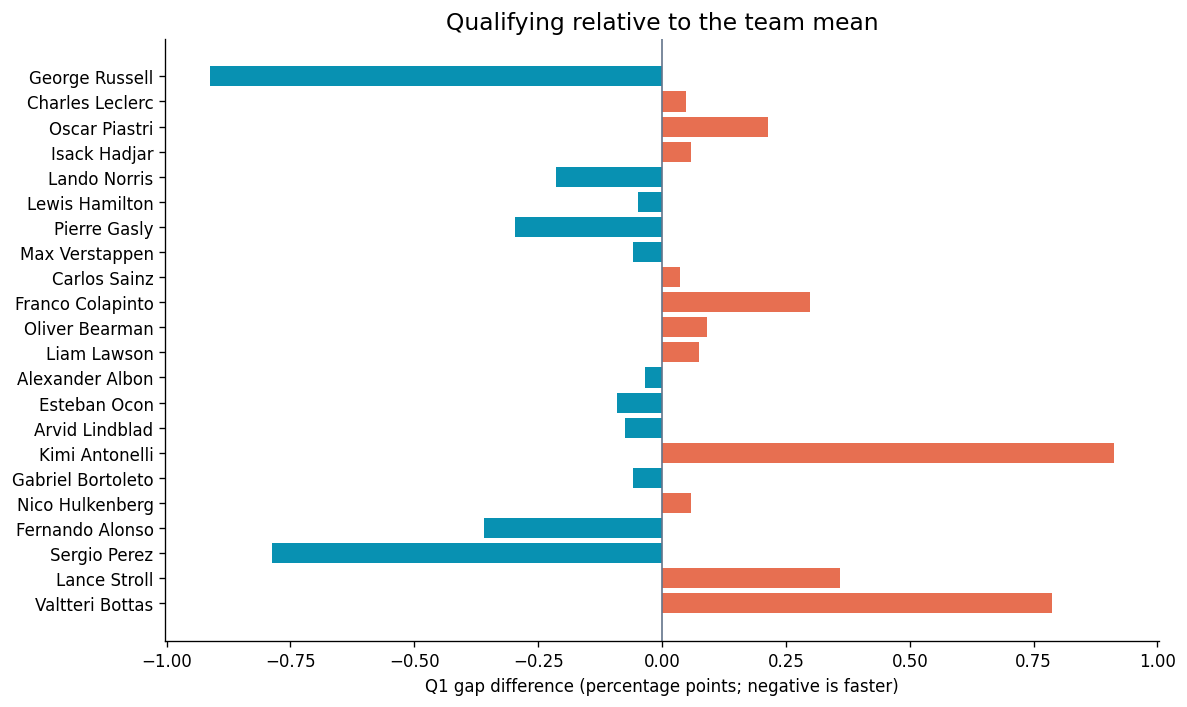

,driver,fp2_longrun_delta,fp2_stint_slope,fp2_longrun_laps
5,Lewis Hamilton,0.393,-0.615667,5
11,Liam Lawson,8.775,-0.556667,5
0,George Russell,NaN,NaN,0
1,Charles Leclerc,NaN,NaN,0
2,Oscar Piastri,NaN,NaN,0
3,Isack Hadjar,NaN,NaN,0
4,Lando Norris,NaN,NaN,0
6,Pierre Gasly,NaN,NaN,0
7,Max Verstappen,NaN,NaN,0
8,Carlos Sainz,NaN,NaN,0


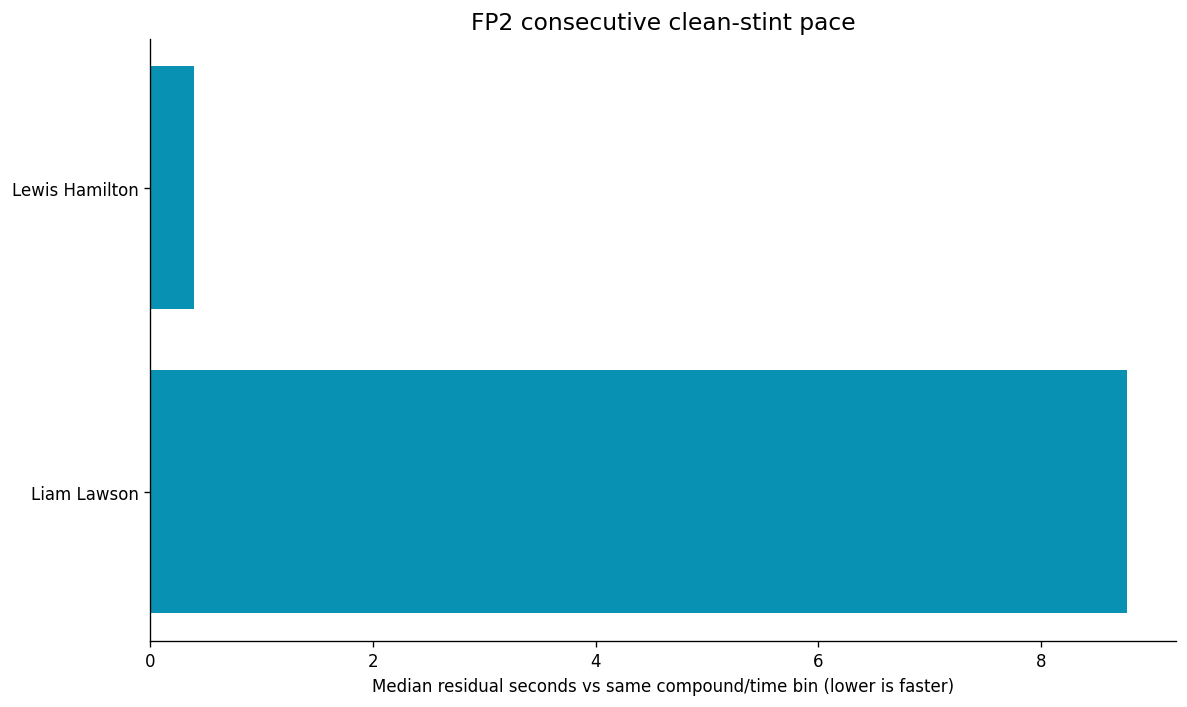

,starts,nonfinish_rate
wet,,
0.0,1504,0.138298
1.0,202,0.178218


In [10]:
(fig, ax) = plt.subplots(figsize=(10, 6))
g = field.sort_values("qual_pos")
ax.barh(
    g.driver,
    g.qual_teammate_gap,
    color=np.where(g.qual_teammate_gap < 0, "#0891b2", "#e76f51"),
)
ax.axvline(0, color="#64748b", linewidth=1)
ax.invert_yaxis()
ax.set(
    title="Qualifying relative to the team mean",
    xlabel="Q1 gap difference (percentage points; negative is faster)",
)
savefig("eda_teammate_qualifying")
if field.fp2_longrun_delta.notna().any():
    display(
        field[
            ["driver", "fp2_longrun_delta", "fp2_stint_slope", "fp2_longrun_laps"]
        ].sort_values("fp2_longrun_delta")
    )
    (fig, ax) = plt.subplots(figsize=(10, 6))
    lr = field.dropna(subset=["fp2_longrun_delta"]).sort_values("fp2_longrun_delta")
    ax.barh(lr.driver, lr.fp2_longrun_delta, color="#0891b2")
    ax.invert_yaxis()
    ax.set(
        title="FP2 consecutive clean-stint pace",
        xlabel="Median residual seconds vs same compound/time bin (lower is faster)",
    )
    savefig("eda_long_runs")
else:
    print("No target lap-level long runs: workbook fastest laps cannot fill this gap.")
if history.wet.notna().any():
    display(
        history.groupby("wet").agg(
            starts=("driverId", "size"), nonfinish_rate=("nonfinish", "mean")
        )
    )
else:
    print(
        "Wet/dry performance unavailable: no labeled historical race-weather context supplied."
    )

## Features before each race

Driver and team form use earlier results. Circuit and wet/dry estimates are shrunk toward
a neutral prior when there is little history. A race updates the history only after its features are built.

In [11]:
STREET_CIRCUITS = {"baku", "monaco", "marina_bay", "jeddah", "vegas"}


def build_features(history, target):
    drivers, teams, circuit_drivers, streets = (
        defaultdict(list),
        defaultdict(list),
        defaultdict(list),
        defaultdict(list),
    )
    circuit_races = defaultdict(list)
    rows = []

    def mean(records, col, last=5):
        v = [r.get(col, np.nan) for r in records[-last:]]
        return float(np.nanmean(v)) if np.isfinite(v).any() else np.nan

    def shrink(records, col, prior=0.0, strength=5):
        v = [r[col] for r in records if np.isfinite(r.get(col, np.nan))]
        return (sum(v) + strength * prior) / (len(v) + strength)

    def make(r):
        d = drivers[r.driverId]
        t = teams[(r.season, r.constructorId)]
        c = circuit_drivers[(r.driverId, r.circuitId)]
        st = streets[r.driverId]
        wet = [x for x in d if x.get("wet") == 1]
        dry = [x for x in d if x.get("wet") == 0]
        corr = circuit_races[r.circuitId]
        return {
            "driver_finish_5": mean(d, "finish_norm"),
            "driver_points_5": mean(d, "points"),
            "driver_win_rate_5": mean(d, "win"),
            "driver_podium_rate_5": mean(d, "podium"),
            "driver_history_count": min(len(d), 5),
            "team_finish_5": mean(t, "finish_norm"),
            "team_points_5": mean(t, "points"),
            "team_trend": mean(t, "qual_norm", 3) - mean(t, "qual_norm", 8),
            "circuit_residual": shrink(c, "residual"),
            "circuit_count": len(c),
            "street_residual": shrink(st[-12:], "residual"),
            "street_count": min(len(st), 12),
            "conversion_5": mean(d, "gain_norm"),
            "driver_nonfinish_rate": shrink(
                d[-20:], "nonfinish", prior=0.15, strength=5
            ),
            "team_nonfinish_rate": shrink(t[-10:], "nonfinish", prior=0.15, strength=5),
            "is_street": float(r.circuitId in STREET_CIRCUITS),
            "circuit_grid_correlation": float(np.mean(corr[-5:])) if corr else np.nan,
            "driver_wet_residual": shrink(wet, "residual"),
            "driver_dry_residual": shrink(dry, "residual"),
            "wet_history_count": len(wet),
            "recent_race_pace": mean(d, "race_pace_delta"),
        }

    for _, race in history.groupby(["date", "race_id"], sort=True):
        for r in race.itertuples():
            rows.append({**r._asdict(), **make(r)})
        for r in race.itertuples():
            rec = r._asdict()
            rec.update(
                win=float(r.position == 1),
                podium=float(r.position <= 3),
                residual=r.finish_norm - r.qual_norm,
            )
            drivers[r.driverId].append(rec)
            circuit_drivers[(r.driverId, r.circuitId)].append(rec)
            if r.circuitId in STREET_CIRCUITS:
                streets[r.driverId].append(rec)
        for team, g in race.groupby("constructorId"):
            teams[(int(g.season.iloc[0]), team)].append(
                {
                    c: float(g[c].mean())
                    for c in ["finish_norm", "points", "qual_norm", "nonfinish"]
                }
            )
        cc = race[["grid_norm", "finish_norm"]].corr(method="spearman").iloc[0, 1]
        if np.isfinite(cc):
            circuit_races[race.circuitId.iloc[0]].append(cc)
    target_features = pd.DataFrame(
        [{**r._asdict(), **make(r)} for r in target.itertuples()]
    )
    return pd.DataFrame(rows), target_features

In [12]:
BASE_FEATURES = [
    "grid_norm",
    "qual_norm",
    "q1_gap_pct",
    "q2_gap_pct",
    "q3_gap_pct",
    "qual_teammate_gap",
    "team_qual_norm",
    "driver_finish_5",
    "driver_points_5",
    "driver_win_rate_5",
    "driver_podium_rate_5",
    "driver_history_count",
    "team_finish_5",
    "team_points_5",
    "team_trend",
    "circuit_residual",
    "circuit_count",
    "street_residual",
    "street_count",
    "conversion_5",
    "driver_nonfinish_rate",
    "team_nonfinish_rate",
    "is_street",
    "circuit_grid_correlation",
    "driver_wet_residual",
    "driver_dry_residual",
    "wet_history_count",
    "recent_race_pace",
]

FP_FEATURES = [
    "fp2_gap_pct",
    "fp2_team_gap_pct",
    "fp2_laps",
    "fp2_longrun_delta",
    "fp2_stint_slope",
    "fp2_longrun_laps",
]

FEATURE_LABELS = {
    "grid_norm": "Starting grid (field-normalized)",
    "qual_norm": "Qualifying position (field-normalized)",
    "q1_gap_pct": "Q1 gap to fastest (%)",
    "q2_gap_pct": "Q2 gap to fastest (%)",
    "q3_gap_pct": "Q3 gap to fastest (%)",
    "qual_teammate_gap": "Q1 gap relative to team mean",
    "team_qual_norm": "Team mean qualifying position",
    "driver_finish_5": "Driver recent finish (last 5 starts)",
    "driver_points_5": "Driver recent points (last 5 starts)",
    "driver_win_rate_5": "Driver recent win rate",
    "driver_podium_rate_5": "Driver recent podium rate",
    "driver_history_count": "Driver history count (up to 5)",
    "team_finish_5": "Team recent finish (last 5 races)",
    "team_points_5": "Team points per car (last 5 races)",
    "team_trend": "Team qualifying trend (3 minus 8 races)",
    "circuit_residual": "Prior circuit finish relative to qualifying",
    "circuit_count": "Prior circuit starts",
    "street_residual": "Prior street-circuit conversion",
    "street_count": "Prior street starts (up to 12)",
    "conversion_5": "Recent grid-to-finish positions gained",
    "driver_nonfinish_rate": "Driver non-finish history",
    "team_nonfinish_rate": "Team non-finish history",
    "is_street": "Street-circuit indicator",
    "circuit_grid_correlation": "Prior circuit grid/finish correlation",
    "driver_wet_residual": "Prior rain-session conversion",
    "driver_dry_residual": "Prior dry-session conversion",
    "wet_history_count": "Prior rain-session sample count",
    "recent_race_pace": "Recent comparable-lap pace (%)",
    "fp2_gap_pct": "FP2 fastest-lap gap (%)",
    "fp2_team_gap_pct": "FP2 team mean gap (%)",
    "fp2_laps": "FP2 recorded lap count",
    "fp2_longrun_delta": "FP2 clean-stint pace residual (seconds)",
    "fp2_stint_slope": "FP2 stint slope (seconds/lap)",
    "fp2_longrun_laps": "FP2 usable long-run lap count",
    "forecast_rain_pct": "Issued forecast rain probability (%)",
    "forecast_temp_c": "Issued forecast temperature (C)",
    "forecast_wind_kmh": "Issued forecast wind (km/h)",
    "wet_skill_x_rain": "Prior wet conversion × issued rain probability",
}

In [13]:
(data, inputs) = build_features(history, field)
data = data.loc[data.season > START_YEAR].reset_index(drop=True)
development = data.loc[data.season.le(2024)]
features = [
    f
    for f in BASE_FEATURES
    if f in data and development[f].notna().any() and (development[f].nunique() > 1)
]
specs = {
    "grid": features,
    "recent_form": features,
    "random_forest": features,
    "gradient_boosting": features,
    "ranker_core": features,
}
fp_features = [
    f
    for f in FP_FEATURES
    if development[f].notna().sum() >= 200
    and development[f].nunique() > 1
    and (inputs[f].notna().mean() >= 0.5)
]
fp_races = development.loc[development.fp2_gap_pct.notna(), "race_id"].nunique()
if fp_races >= 30 and fp_features:
    specs["ranker_fp2"] = features + fp_features
print(
    "FP2 comparison:",
    f"{fp_races} historical development races; features {fp_features}",
)
feature_coverage = pd.DataFrame({"feature": BASE_FEATURES + FP_FEATURES})
feature_coverage["development_coverage"] = feature_coverage.feature.map(
    lambda f: development[f].notna().mean() if f in development else 0
)
feature_coverage["target_coverage"] = feature_coverage.feature.map(
    lambda f: inputs[f].notna().mean() if f in inputs else 0
)
feature_coverage["meaning"] = feature_coverage.feature.map(FEATURE_LABELS)
display(
    feature_coverage[["feature", "development_coverage", "target_coverage"]].round(2)
)
assert not {
    "position",
    "points",
    "status",
    "nonfinish",
    "finish_norm",
    "wet",
    "race_pace_delta",
} & set(sum(specs.values(), []))
feature_coverage.to_csv(OUT / "feature_coverage.csv", index=False)

FP2 comparison: 34 historical development races; features ['fp2_gap_pct', 'fp2_team_gap_pct', 'fp2_laps', 'fp2_longrun_laps']


,feature,development_coverage,target_coverage
0,grid_norm,1.00,1.00
1,qual_norm,1.00,1.00
2,q1_gap_pct,0.99,1.00
3,q2_gap_pct,0.74,0.68
4,q3_gap_pct,0.49,0.45
5,qual_teammate_gap,0.99,1.00
6,team_qual_norm,1.00,1.00
7,driver_finish_5,0.99,1.00
8,driver_points_5,0.99,1.00
9,driver_win_rate_5,0.99,1.00


## Comparing the models

Each validation race is held out as a complete event. Model selection uses 2023–2024;
2025 and 2026 are reported separately. Lower MAE is better. Top-3 and top-10 overlap
measure which drivers were correctly included, regardless of order.

In [14]:
def metric_row(g, pred):
    from scipy.stats import spearmanr

    truth = g.position.to_numpy()
    pred = np.asarray(pred)
    n = len(g)
    i, j = np.triu_indices(n, 1)
    return {
        "mae": float(np.abs(truth - pred).mean()),
        "spearman": float(spearmanr(truth, pred).statistic),
        "top3_overlap": float(((truth <= 3) & (pred <= 3)).sum() / 3),
        "top10_overlap": float(((truth <= 10) & (pred <= 10)).sum() / min(10, n)),
        "pairwise_accuracy": float(
            ((truth[i] - truth[j]) * (pred[i] - pred[j]) > 0).mean()
        ),
    }


def order_scores(scores, frame):
    # Higher scores mean better. Deterministic ties use qualifying then stable ID.
    tmp = pd.DataFrame(
        {
            "score": scores,
            "q": frame.qual_pos.to_numpy(),
            "id": frame.driverId.to_numpy(),
        }
    )
    order = tmp.sort_values(
        ["score", "q", "id"], ascending=[False, True, True], na_position="last"
    ).index.to_numpy()
    ranks = np.empty(len(tmp), dtype=int)
    ranks[order] = np.arange(1, len(tmp) + 1)
    return ranks


def new_model(kind):
    from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
    from sklearn.pipeline import make_pipeline
    from sklearn.impute import SimpleImputer
    from xgboost import XGBRanker

    if kind == "random_forest":
        return make_pipeline(
            SimpleImputer(
                strategy="median", add_indicator=True, keep_empty_features=True
            ),
            RandomForestRegressor(
                n_estimators=160,
                min_samples_leaf=12,
                max_features=0.8,
                random_state=SEED,
                n_jobs=2,
            ),
        )
    if kind == "gradient_boosting":
        return HistGradientBoostingRegressor(
            max_iter=120,
            max_leaf_nodes=7,
            l2_regularization=5,
            learning_rate=0.05,
            random_state=SEED,
        )
    if kind.startswith("ranker"):
        return XGBRanker(
            objective="rank:pairwise",
            n_estimators=140,
            max_depth=3,
            learning_rate=0.04,
            reg_lambda=8,
            min_child_weight=8,
            tree_method="hist",
            n_jobs=2,
            random_state=SEED,
        )
    return None


def fit_model(kind, train, features):
    m = new_model(kind)
    if m is None:
        return None
    train = train.sort_values(["date", "race_id", "driverId"])
    if kind.startswith("ranker"):
        # Integer relevance: best classified driver has highest relevance.
        m.fit(
            train[features],
            (train.n - train.position).astype(int),
            group=train.groupby("race_id", sort=False).size().to_numpy(),
        )
    else:
        m.fit(train[features], train.finish_norm)
    return m


def scores_for(kind, model, frame, features):
    if kind == "grid":
        return -frame.grid_norm.to_numpy()
    if kind == "recent_form":
        return -frame.driver_finish_5.fillna(0.5).to_numpy()
    v = model.predict(frame[features])
    return v if kind.startswith("ranker") else -v

In [15]:
def walk_forward(data, specs, validation_since=2023):
    predictions, metrics, folds = [], [], []
    races = (
        data.loc[data.season.ge(validation_since), ["race_id", "date"]]
        .drop_duplicates()
        .sort_values("date")
    )
    for count, r in enumerate(races.itertuples(), 1):
        train = data.loc[data.date < r.date].copy()
        valid = data.loc[data.race_id.eq(r.race_id)].copy()
        if train.race_id.nunique() < 30:
            continue
        assert train.date.max() < valid.date.min()
        folds.append(
            {
                "race_id": r.race_id,
                "train_through": train.date.max(),
                "validation_date": r.date,
                "train_races": train.race_id.nunique(),
            }
        )
        for kind, features in specs.items():
            model = fit_model(kind, train, features)
            pred = order_scores(scores_for(kind, model, valid, features), valid)
            keep = valid[
                [
                    "race_id",
                    "date",
                    "season",
                    "circuitId",
                    "driverId",
                    "driver",
                    "position",
                    "n",
                    "qual_pos",
                ]
            ].copy()
            keep["predicted_rank"] = pred
            keep["model"] = kind
            keep["residual_norm"] = (keep.position - keep.predicted_rank) / (keep.n - 1)
            predictions.append(keep)
            metrics.append(
                {
                    "race_id": r.race_id,
                    "date": r.date,
                    "season": int(valid.season.iloc[0]),
                    "circuitId": valid.circuitId.iloc[0],
                    "model": kind,
                    **metric_row(valid, pred),
                }
            )
        if count % 5 == 0:
            print(f"Validated {count}/{len(races)} races", flush=True)
    return (
        pd.concat(predictions, ignore_index=True),
        pd.DataFrame(metrics),
        pd.DataFrame(folds),
    )

Selected model: ranker_fp2


,mae,spearman,top3_overlap,top10_overlap,pairwise_accuracy
model,,,,,
ranker_fp2,3.085,0.707,0.667,0.835,0.784
ranker_core,3.096,0.704,0.674,0.830,0.782
gradient_boosting,3.118,0.702,0.623,0.822,0.780
random_forest,3.125,0.703,0.601,0.830,0.782
grid,3.306,0.661,0.652,0.789,0.765
recent_form,3.830,0.600,0.522,0.748,0.727


mae  spearman  top3_overlap  \
period            model                                              
2023–24 selection gradient_boosting  3.118     0.702         0.623   
                  grid               3.306     0.661         0.652   
                  random_forest      3.125     0.703         0.601   
                  ranker_core        3.096     0.704         0.674   
                  ranker_fp2         3.085     0.707         0.667   
                  recent_form        3.830     0.600         0.522   
2025 calibration  gradient_boosting  3.316     0.661         0.722   
                  grid               3.344     0.651         0.750   
                  random_forest      3.266     0.664         0.750   
                  ranker_core        3.278     0.663         0.750   
                  ranker_fp2         3.303     0.666         0.736   
                  recent_form        4.259     0.514         0.583   
2026 audit        gradient_boosting  3.442     0.673         0.571   
                  grid               3.403     0.650         0.619   
                  random_forest      3.390     0.676         0.595   
                  ranker_core        3.481     0.662         0.548   
                  ranker_fp2         3.429     0.668         0.571   
                  recent_form        4.364     0.566         0.333   

                                     top10_overlap  pairwise_accuracy  
period            model                                                
2023–24 selection gradient_boosting          0.822              0.780  
                  grid                       0.789              0.765  
                  random_forest              0.830              0.782  
                  ranker_core                0.830              0.782  
                  ranker_fp2                 0.835              0.784  
                  recent_form                0.748              0.727  
2025 calibration  gradient_boosting          0.763              0.765  
                  grid                       0.779              0.756  
                  random_forest              0.771              0.766  
                  ranker_core                0.767              0.764  
                  ranker_fp2                 0.758              0.767  
                  recent_form                0.683              0.690  
2026 audit        gradient_boosting          0.779              0.787  
                  grid                       0.750              0.777  
                  random_forest              0.779              0.787  
                  ranker_core                0.779              0.785  
                  ranker_fp2                 0.779              0.786  
                  recent_form                0.693              0.719

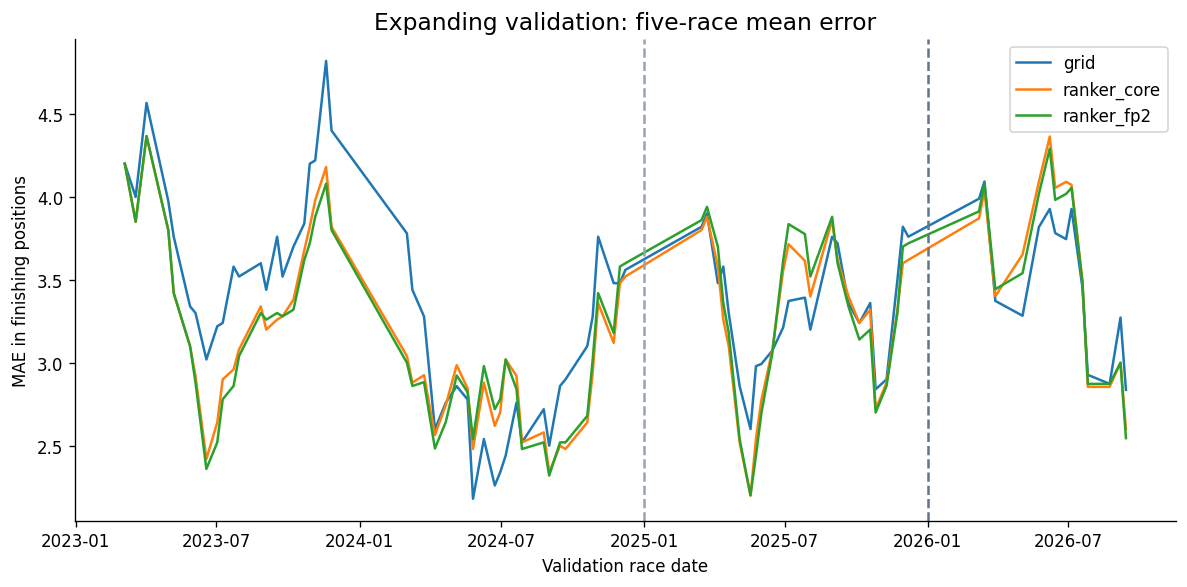

In [16]:
with capture_output():
    (oof, metrics, folds) = walk_forward(data, specs, validation_since=2023)
dev_metrics = metrics.loc[metrics.season.le(2024)]
assert dev_metrics.race_id.nunique() >= 20
selection = dev_metrics.groupby("model")[
    ["mae", "spearman", "top3_overlap", "top10_overlap", "pairwise_accuracy"]
].mean()
selection = selection.sort_values(["mae", "pairwise_accuracy"], ascending=[True, False])
CHOSEN = selection.index[0]
print("Selected model:", CHOSEN)
display(selection.round(3))
metrics["period"] = np.select(
    [metrics.season.le(2024), metrics.season.eq(2025)],
    ["2023–24 selection", "2025 calibration"],
    default="2026 audit",
)
display(
    metrics.groupby(["period", "model"])[
        ["mae", "spearman", "top3_overlap", "top10_overlap", "pairwise_accuracy"]
    ]
    .mean()
    .round(3)
)
folds.to_csv(OUT / "validation_folds.csv", index=False)
metrics.to_csv(OUT / "race_metrics.csv", index=False)
oof.to_csv(OUT / "out_of_fold_predictions.csv", index=False)
(fig, ax) = plt.subplots(figsize=(10, 5))
for (kind, g) in metrics.groupby("model"):
    if kind in [CHOSEN, "grid", "ranker_core", "ranker_fp2"]:
        ax.plot(
            pd.to_datetime(g.date), g.mae.rolling(5, min_periods=1).mean(), label=kind
        )
ax.axvline(pd.Timestamp("2025-01-01", tz="UTC"), color="#94a3b8", linestyle="--")
ax.axvline(pd.Timestamp("2026-01-01", tz="UTC"), color="#64748b", linestyle="--")
ax.set(
    title="Expanding validation: five-race mean error",
    ylabel="MAE in finishing positions",
    xlabel="Validation race date",
)
ax.legend()
savefig("model_validation")

## How uncertain is the forecast?

I resample earlier out-of-fold race errors to generate complete finishing orders.
The probabilities are approximate; zero in these simulations does not mean impossible.

In [17]:
def simulate_order(base_ranks, calibration, draws=6000, seed=SEED):
    """Resample whole-race rank-error vectors aligned by predicted percentile.

    Preserves broad shared-event structure. Interpolate for 20/22-car fields.
    Includes empirical retirement tails; no second DNF penalty is added.
    """
    rng = np.random.default_rng(seed)
    n = len(base_ranks)
    races = [g.sort_values("predicted_rank") for _, g in calibration.groupby("race_id")]
    if len(races) < 10:
        raise ValueError("At least ten earlier OOF races needed for uncertainty.")
    base = (np.asarray(base_ranks) - 1) / (n - 1)
    simulated = np.empty((draws, n), dtype=int)
    for b in range(draws):
        g = races[rng.integers(len(races))]
        xp = (g.predicted_rank.to_numpy() - 1) / (len(g) - 1)
        eps = np.interp(base, xp, g.residual_norm.to_numpy())
        latent = base + eps + rng.normal(0, 1e-6, n)
        order = np.argsort(latent, kind="stable")
        simulated[b, order] = np.arange(1, n + 1)
    assert np.all(np.sort(simulated, axis=1) == np.arange(1, n + 1))
    return simulated


def probability_audit(oof, chosen, calibration_year=2025, audit_year=2026):
    p = oof.loc[oof.model.eq(chosen)].copy()
    rows = []
    for race, g in p.loc[p.season.ge(audit_year)].groupby("race_id", sort=True):
        earlier = p.loc[p.date.lt(g.date.min()) & p.season.ge(calibration_year)]
        if earlier.race_id.nunique() < 10:
            continue
        sim = simulate_order(g.predicted_rank.to_numpy(), earlier, draws=2000)
        lo, hi = np.quantile(sim, [0.1, 0.9], axis=0, method="nearest")
        prob = (sim <= 3).mean(axis=0)
        y = g.position.le(3).to_numpy()
        for k, r in enumerate(g.itertuples()):
            rows.append(
                {
                    "race_id": race,
                    "driverId": r.driverId,
                    "podium_probability": prob[k],
                    "podium_actual": int(y[k]),
                    "covered80": int(lo[k] <= r.position <= hi[k]),
                    "interval_width": hi[k] - lo[k],
                    "brier": float((prob[k] - y[k]) ** 2),
                }
            )
    return pd.DataFrame(rows)

,model,audit_races,mean_mae,race_bootstrap_lo,race_bootstrap_hi
0,gradient_boosting,14,3.442,2.805,4.117
1,grid,14,3.403,2.850,3.974
2,random_forest,14,3.390,2.799,3.994
3,ranker_core,14,3.481,2.838,4.143
4,ranker_fp2,14,3.429,2.792,4.104
5,recent_form,14,4.364,3.812,4.987


brier              0.070832
covered80          0.837662
interval_width    11.136364
Name: 2026 audit, dtype: float64

,predicted,observed,n
podium_probability,,,
"(-0.001, 0.1]",0.010278,0.013889,216
"(0.1, 0.25]",0.133431,0.166667,36
"(0.25, 0.5]",0.406522,0.521739,23
"(0.5, 0.75]",0.648708,0.583333,12
"(0.75, 1.0]",0.849619,0.666667,21


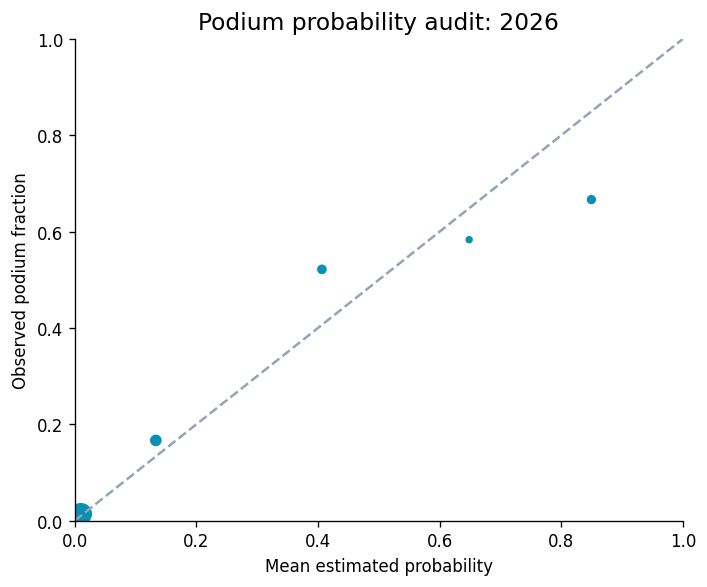

In [18]:
audit = metrics.loc[metrics.season.eq(2026)]
rng = np.random.default_rng(42)
bootstrap = []
for (kind, g) in audit.groupby("model"):
    vals = g.mae.to_numpy()
    samples = rng.choice(vals, size=(3000, len(vals)), replace=True).mean(axis=1)
    bootstrap.append(
        {
            "model": kind,
            "audit_races": len(vals),
            "mean_mae": vals.mean(),
            "race_bootstrap_lo": np.quantile(samples, 0.025),
            "race_bootstrap_hi": np.quantile(samples, 0.975),
        }
    )
display(pd.DataFrame(bootstrap).round(3))
prob_audit = probability_audit(oof, CHOSEN)
if not prob_audit.empty:
    display(
        prob_audit[["brier", "covered80", "interval_width"]].mean().rename("2026 audit")
    )
    bins = pd.cut(
        prob_audit.podium_probability, [0, 0.1, 0.25, 0.5, 0.75, 1], include_lowest=True
    )
    reliability = prob_audit.groupby(bins, observed=True).agg(
        predicted=("podium_probability", "mean"),
        observed=("podium_actual", "mean"),
        n=("podium_actual", "size"),
    )
    display(reliability)
    (fig, ax) = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], linestyle="--", color="#94a3b8")
    ax.scatter(
        reliability.predicted,
        reliability.observed,
        s=reliability.n.clip(upper=150),
        color="#0891b2",
    )
    ax.set(
        title="Podium probability audit: 2026",
        xlabel="Mean estimated probability",
        ylabel="Observed podium fraction",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    savefig("probability_reliability")
else:
    print("Not enough later audit races for probability diagnostics.")
prob_audit.to_csv(OUT / "probability_audit.csv", index=False)

## My Baku prediction

The best development model is refit on all eligible earlier races. The intervals include
historical non-finish outcomes, but cannot anticipate a particular strategy or incident.

Model: ranker_fp2 | Empirical error races: 38
Grid: Derived provisional grid: workbook qualifying plus documented Aston Martin back-of-grid penalties; final FIA grid and pending investigations unconfirmed


,predicted_position,driver,team,qual_pos,expected_finish,p10_position,p90_position,podium_probability,top10_probability
0,1,George Russell,Mercedes,1,3.194,1,15,0.872,0.899
1,2,Charles Leclerc,Ferrari,2,4.060,1,9,0.740,0.921
2,3,Isack Hadjar,Red Bull Racing,4,6.286,1,20,0.437,0.848
3,4,Oscar Piastri,McLaren,3,6.361,2,17,0.419,0.810
4,5,Lando Norris,McLaren,5,6.128,3,14,0.156,0.869
5,6,Max Verstappen,Red Bull Racing,8,6.758,3,11,0.130,0.877
6,7,Lewis Hamilton,Ferrari,6,8.277,3,14,0.106,0.754
7,8,Kimi Antonelli,Mercedes,16,10.641,5,21,0.083,0.640
8,9,Pierre Gasly,Alpine,7,10.899,6,19,0.000,0.582
9,10,Franco Colapinto,Alpine,10,9.918,5,20,0.000,0.691


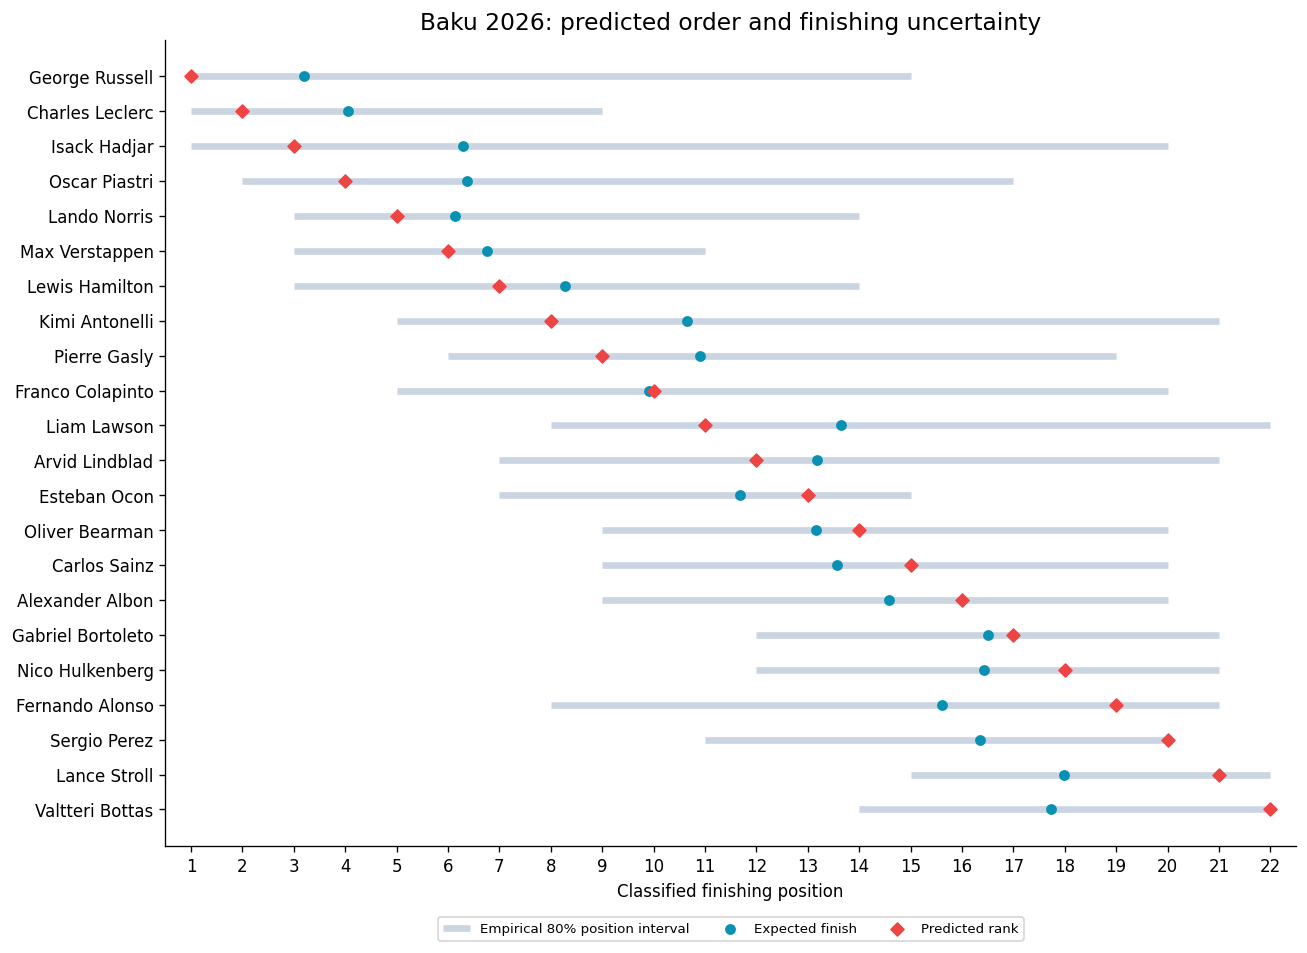

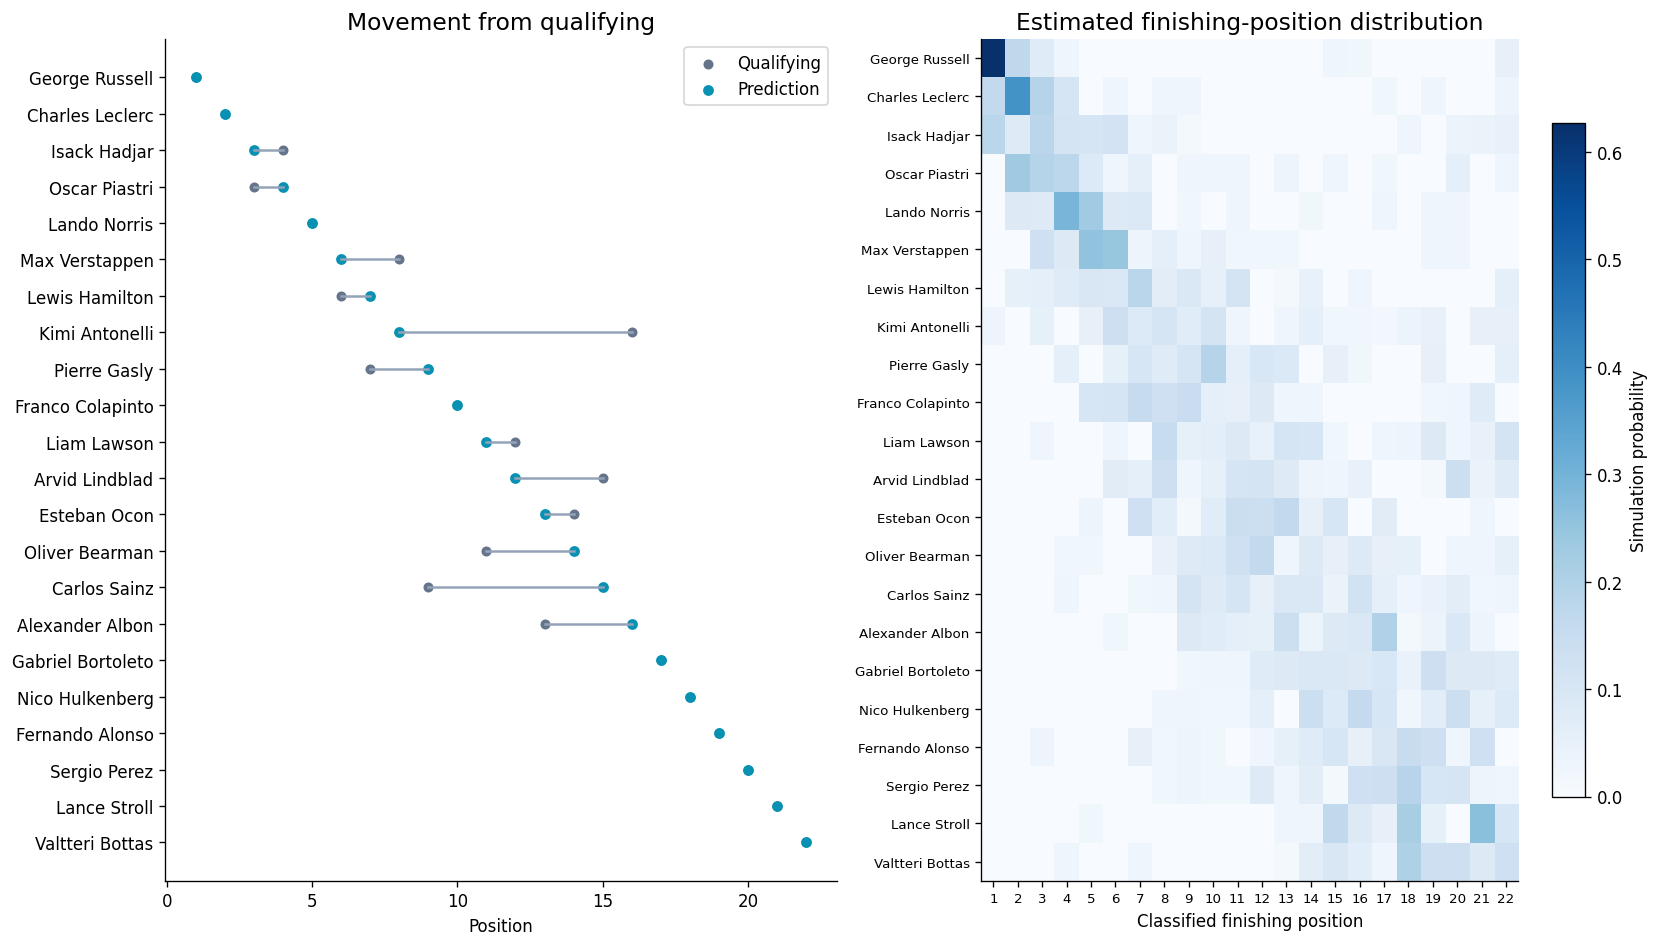

In [19]:
selected_features = specs[CHOSEN]
model = fit_model(CHOSEN, data, selected_features)
scores = scores_for(CHOSEN, model, inputs, selected_features)
ranks = order_scores(scores, inputs)
calibration = oof.loc[
    oof.model.eq(CHOSEN) & oof.season.ge(2025) & oof.date.lt(AS_OF_UTC)
].copy()
sim = simulate_order(ranks, calibration, draws=N_SIMULATIONS)
(lo, hi) = np.quantile(sim, [0.1, 0.9], axis=0, method="nearest")
prediction = inputs[
    ["driverId", "driver", "team", "qual_pos", "grid", "grid_source", "grid_status"]
].copy()
prediction["predicted_position"] = ranks
prediction["expected_finish"] = sim.mean(axis=0)
prediction["p10_position"] = lo.astype(int)
prediction["p90_position"] = hi.astype(int)
prediction["podium_probability"] = (sim <= 3).mean(axis=0)
prediction["win_probability"] = (sim == 1).mean(axis=0)
prediction["top10_probability"] = (sim <= 10).mean(axis=0)
prediction["places_vs_qualifying"] = prediction.qual_pos - prediction.predicted_position
prediction = prediction.sort_values("predicted_position").reset_index(drop=True)
assert sorted(prediction.predicted_position) == list(range(1, len(inputs) + 1))
assert np.isclose(prediction.podium_probability.sum(), 3)
assert np.isclose(prediction.win_probability.sum(), 1)
assert np.isclose(prediction.top10_probability.sum(), 10)
print("Model:", CHOSEN, "| Empirical error races:", calibration.race_id.nunique())
print("Grid:", prediction.grid_status.iloc[0])
display(
    prediction[
        [
            "predicted_position",
            "driver",
            "team",
            "qual_pos",
            "expected_finish",
            "p10_position",
            "p90_position",
            "podium_probability",
            "top10_probability",
        ]
    ].round(3)
)
(fig, ax) = plt.subplots(figsize=(11, 8))
y = np.arange(len(prediction))
ax.hlines(
    y,
    prediction.p10_position,
    prediction.p90_position,
    color="#cbd5e1",
    linewidth=4,
    zorder=1,
    label="Empirical 80% position interval",
)
ax.scatter(
    prediction.expected_finish,
    y,
    s=30,
    color="#0891b2",
    zorder=3,
    label="Expected finish",
)
ax.scatter(
    prediction.predicted_position,
    y,
    s=30,
    color="#ef4444",
    marker="D",
    zorder=3,
    label="Predicted rank",
)
ax.set_yticks(y, prediction.driver)
ax.invert_yaxis()
ax.set_xticks(range(1, len(prediction) + 1))
ax.set_xlim(0.5, len(prediction) + 0.5)
ax.set(
    title="Baku 2026: predicted order and finishing uncertainty",
    xlabel="Classified finishing position",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
savefig("predicted_finishing_order")
(fig, axes) = plt.subplots(1, 2, figsize=(14, 8))
for (i, r) in enumerate(prediction.itertuples()):
    axes[0].plot([r.qual_pos, r.predicted_position], [i, i], color="#94a3b8")
axes[0].scatter(prediction.qual_pos, y, label="Qualifying", color="#64748b", s=25)
axes[0].scatter(
    prediction.predicted_position, y, label="Prediction", color="#0891b2", s=30
)
axes[0].set_yticks(y, prediction.driver)
axes[0].invert_yaxis()
axes[0].set(title="Movement from qualifying", xlabel="Position")
axes[0].legend()
ordered_indices = [
    int(np.where(inputs.driverId.to_numpy() == d)[0][0]) for d in prediction.driverId
]
probabilities = np.array(
    [
        (sim[:, i, None] == np.arange(1, len(inputs) + 1)).mean(axis=0)
        for i in ordered_indices
    ]
)
im = axes[1].imshow(probabilities, aspect="auto", cmap="Blues", vmin=0)
axes[1].set_yticks(y, prediction.driver, fontsize=8)
axes[1].set_xticks(range(len(inputs)), range(1, len(inputs) + 1), fontsize=8)
axes[1].set(
    title="Estimated finishing-position distribution",
    xlabel="Classified finishing position",
)
fig.colorbar(im, ax=axes[1], label="Simulation probability", shrink=0.8)
savefig("qualifying_movement_and_probabilities")

## What drives the order?

Permutation importance uses held-out races. SHAP explains ranking scores, not causal effects
or positions gained.

In [20]:
def permutation_importance_races(model, kind, frame, features, repeats=4):
    """Within-race permutations; evaluate on a held-out block only."""
    rng = np.random.default_rng(SEED)

    def mae(f):
        values = []
        for _, g in f.groupby("race_id"):
            pred = order_scores(scores_for(kind, model, g, features), g)
            values.append(np.abs(pred - g.position.to_numpy()).mean())
        return float(np.mean(values))

    base = mae(frame)
    rows = []
    for feature in features:
        losses = []
        for _ in range(repeats):
            shuffled = frame.copy()
            for _, idx in shuffled.groupby("race_id").groups.items():
                shuffled.loc[idx, feature] = rng.permutation(
                    shuffled.loc[idx, feature].to_numpy()
                )
            losses.append(mae(shuffled) - base)
        rows.append(
            {"feature": feature, "mae_increase": np.mean(losses), "std": np.std(losses)}
        )
    return pd.DataFrame(rows).sort_values("mae_increase", ascending=False)

,feature,mae_increase,std
0,grid_norm,0.453,0.114
4,q3_gap_pct,0.159,0.029
6,team_qual_norm,0.137,0.027
1,qual_norm,0.073,0.024
27,recent_race_pace,0.069,0.030
3,q2_gap_pct,0.068,0.024
8,driver_points_5,0.058,0.042
13,team_points_5,0.053,0.007
19,conversion_5,0.051,0.009
12,team_finish_5,0.039,0.022


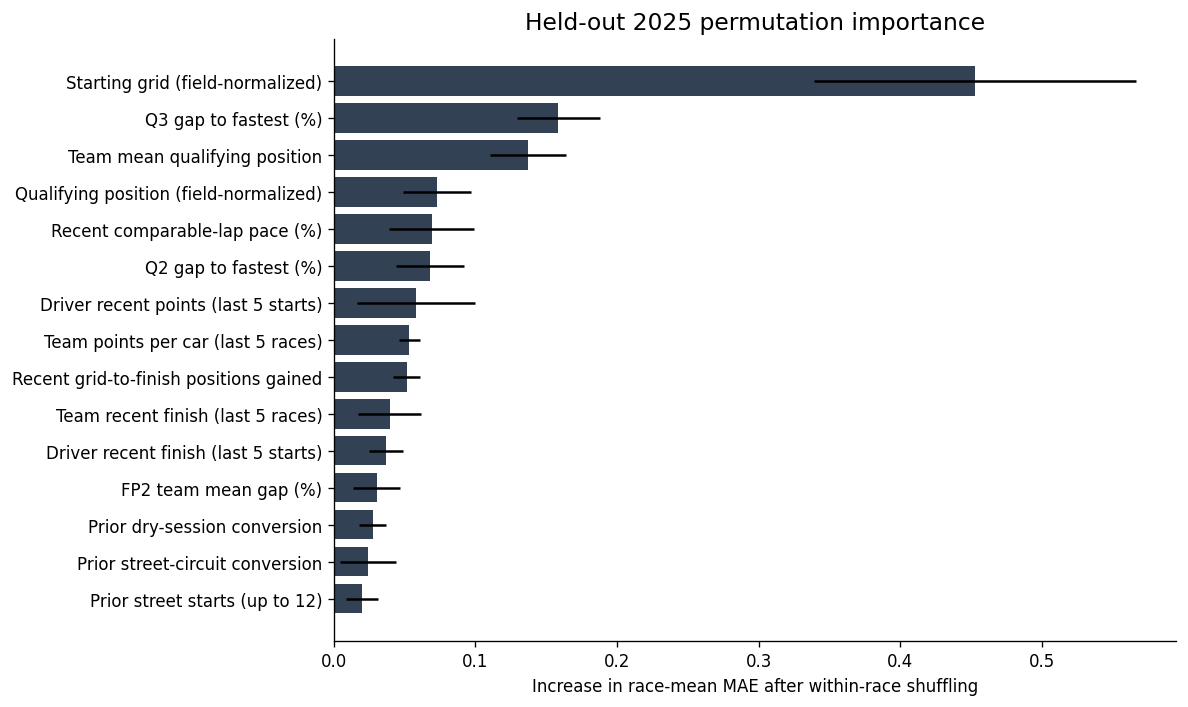

,predicted_position,driver,places_vs_qualifying,key_factors
0,1,George Russell,0,Starting grid (field-normalized): +0.312; Q3 g...
1,2,Charles Leclerc,0,Starting grid (field-normalized): +0.355; Qual...
2,3,Isack Hadjar,1,Starting grid (field-normalized): +0.255; Qual...
3,4,Oscar Piastri,-1,Starting grid (field-normalized): +0.237; Qual...
4,5,Lando Norris,0,Starting grid (field-normalized): +0.222; Team...
5,6,Max Verstappen,2,Team points per car (last 5 races): +0.119; St...
6,7,Lewis Hamilton,-1,Starting grid (field-normalized): +0.147; Team...
7,8,Kimi Antonelli,8,Team points per car (last 5 races): +0.162; Dr...
8,9,Pierre Gasly,-2,Starting grid (field-normalized): +0.132; Qual...
9,10,Franco Colapinto,0,Q3 gap to fastest (%): -0.076; Starting grid (...


In [21]:
explain_train = data.loc[data.season.le(2024)]
explain_test = data.loc[data.season.eq(2025)]
explain_model = fit_model(CHOSEN, explain_train, selected_features)
importance = permutation_importance_races(
    explain_model, CHOSEN, explain_test, selected_features
)
display(importance.head(15).round(3))
(fig, ax) = plt.subplots(figsize=(10, 6))
imp = importance.head(15).sort_values("mae_increase")
ax.barh(
    imp.feature.map(lambda f: FEATURE_LABELS.get(f, f)),
    imp.mae_increase,
    xerr=imp["std"],
    color="#334155",
)
ax.set(
    title="Held-out 2025 permutation importance",
    xlabel="Increase in race-mean MAE after within-race shuffling",
)
savefig("feature_importance")
if CHOSEN.startswith("ranker"):
    import xgboost as xgb

    contrib = model.get_booster().predict(
        xgb.DMatrix(inputs[selected_features]), pred_contribs=True
    )
    assert np.allclose(contrib.sum(axis=1), scores, atol=0.0001)
    local = pd.DataFrame(
        contrib[:, :-1], columns=selected_features, index=inputs.driverId
    )
    explanation_type = (
        "Exact tree SHAP; positive supports better rank; latent score units"
    )
else:
    local = pd.DataFrame(0.0, index=inputs.driverId, columns=selected_features)
    if CHOSEN == "grid":
        local["grid_norm"] = -inputs.grid_norm.to_numpy() + float(
            data.grid_norm.median()
        )
    elif CHOSEN == "recent_form":
        local["driver_finish_5"] = -inputs.driver_finish_5.fillna(
            0.5
        ).to_numpy() + float(data.driver_finish_5.median())
    else:
        for f in selected_features:
            changed = inputs.copy()
            changed[f] = data[f].median()
            local[f] = scores - scores_for(CHOSEN, model, changed, selected_features)
    explanation_type = (
        "One-feature training-median replacement sensitivity; not SHAP or causation"
    )
reasons = []
for r in prediction.itertuples():
    effects = local.loc[r.driverId]
    top = effects.abs().sort_values(ascending=False).head(3).index
    reasons.append(
        "; ".join(
            (
                f"{FEATURE_LABELS.get(f, f)}: {effects[f]:+.3f}"
                for f in top
                if abs(effects[f]) > 1e-10
            )
        )
    )
prediction["key_factors"] = reasons
prediction["explanation_type"] = explanation_type
display(
    prediction[["predicted_position", "driver", "places_vs_qualifying", "key_factors"]]
)
local.to_csv(OUT / "driver_feature_contributions.csv")
importance.to_csv(OUT / "permutation_importance.csv", index=False)

## Save the forecast

In [22]:
prediction.to_csv(OUT / "baku_predictions.csv", index=False)
print("Saved results/baku_predictions.csv")

Saved results/baku_predictions.csv
